# Solver de la Ecuación de Schrödinger usando el Método de Numerov

Este notebook implementa un solver numérico para la ecuación de Schrödinger independiente del tiempo con potencial arbitrario usando el método de Numerov.

## Ecuación de Schrödinger

La ecuación de Schrödinger independiente del tiempo es:

$$-\frac{\hbar^2}{2m}\frac{d^2\psi}{dx^2} + V(x)\psi(x) = E\psi(x)$$

Reordenando:

$$\frac{d^2\psi}{dx^2} = \frac{2m}{\hbar^2}[V(x) - E]\psi(x)$$

## 1. Importar Librerías Necesarias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy.integrate import simpson

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## 2. Método de Numerov

El método de Numerov es un algoritmo eficiente para resolver ecuaciones diferenciales de segundo orden de la forma:

$$\frac{d^2y}{dx^2} = -g(x)y(x)$$

Para la ecuación de Schrödinger, tenemos:

$$g(x) = \frac{2m}{\hbar^2}[E - V(x)]$$

El método de Numerov proporciona una fórmula de recurrencia:

$$\psi_{n+1} = \frac{2\psi_n(1 - \frac{5h^2}{12}g_n) - \psi_{n-1}(1 + \frac{h^2}{12}g_{n-1})}{1 + \frac{h^2}{12}g_{n+1}}$$

donde $h$ es el paso de integración.

In [2]:
def numerov(x, V, E, psi0, psi1, hbar=1.0, m=1.0):
    """
    Método de Numerov para resolver la ecuación de Schrödinger.
    
    Parámetros:
    -----------
    x : array
        Grid de puntos espaciales
    V : array
        Potencial en cada punto
    E : float
        Energía de prueba
    psi0 : float
        Condición inicial psi(x[0])
    psi1 : float
        Condición inicial psi(x[1])
    hbar : float
        Constante de Planck reducida (por defecto 1.0 en unidades atómicas)
    m : float
        Masa de la partícula (por defecto 1.0 en unidades atómicas)
    
    Retorna:
    --------
    psi : array
        Función de onda en cada punto
    """
    n = len(x)
    h = x[1] - x[0]
    psi = np.zeros(n)
    
    # Condiciones iniciales
    psi[0] = psi0
    psi[1] = psi1
    
    # Función g(x) = 2m(E - V(x))/hbar^2
    g = 2.0 * m * (E - V) / hbar**2
    
    # Coeficientes para el método de Numerov
    c0 = 1.0 + h**2 * g / 12.0
    c1 = 2.0 * (1.0 - 5.0 * h**2 * g / 12.0)
    
    # Propagación hacia adelante
    for i in range(1, n-1):
        psi[i+1] = (c1[i] * psi[i] - c0[i-1] * psi[i-1]) / c0[i+1]
    
    return psi

## 3. Definir el Potencial: Pozo Finito

Implementamos un pozo de potencial finito:

$$V(x) = \begin{cases} 
0 & \text{si } |x| < a \\
V_0 & \text{si } |x| \geq a 
\end{cases}$$

Este potencial tiene soluciones analíticas conocidas que nos permitirán verificar nuestro método numérico.

In [3]:
# Parámetros del sistema (en unidades atómicas: hbar = m = 1)
hbar = 1.0
m = 1.0

# Parámetros del pozo finito
a = np.pi/2         # Semi-ancho del pozo
V0 = 100.0        # Profundidad del pozo

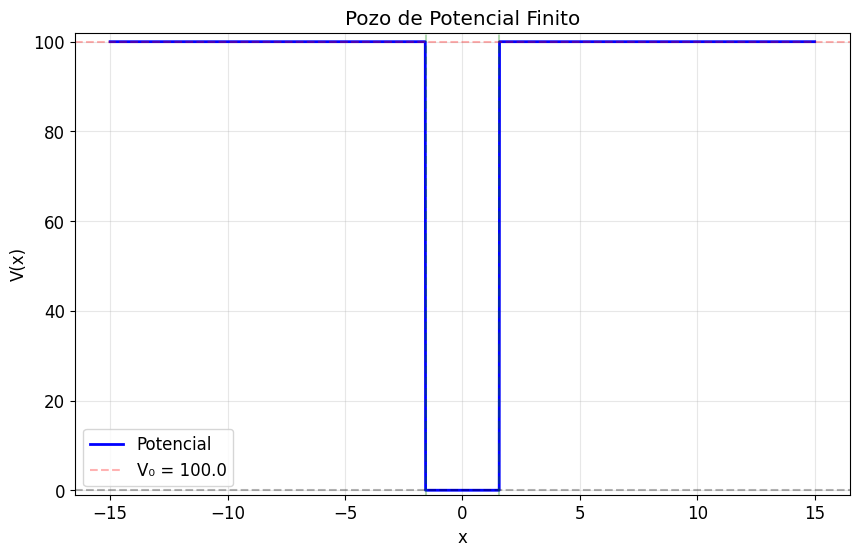

Parámetros del sistema (ADAPTABLES):
  Semi-ancho del pozo: a = 1.5707963267948966
  Profundidad del pozo: V₀ = 100.0

Estimación automática:
  Estados ligados estimados: 15
  Rango espacial: [-15.0, 15.0]
  Grid espacial: 2250 puntos
  Paso de integración: h = 0.013339
  Puntos de búsqueda para eigenvalores: 3750
  Tolerancia de filtro: 0.100000


In [4]:
def finite_well(x, a, V0):
    """
    Pozo de potencial finito.
    
    Parámetros:
    -----------
    x : array
        Grid de puntos espaciales
    a : float
        Semi-ancho del pozo
    V0 : float
        Profundidad del pozo (V0 > 0)
    
    Retorna:
    --------
    V : array
        Potencial en cada punto
    """
    V = np.zeros_like(x)
    V[np.abs(x) >= a] = V0
    return V

# ============================================================================
# FUNCIÓN PARA HACER EL CÓDIGO ADAPTABLE A LOS PARÁMETROS
# ============================================================================

def estimate_and_optimize_parameters(a, V0, hbar, m):
    """
    Estima el número de estados ligados y calcula parámetros óptimos
    para la búsqueda numérica adaptados a los parámetros del sistema.
    
    Retorna:
    --------
    dict con parámetros optimizados
    """
    # 1. Estimar número de estados ligados usando la fórmula de pozo finito
    # N ≈ (a/π)√(8mV₀/ℏ²)
    N_states_est = int((a / np.pi) * np.sqrt(8 * m * V0 / hbar**2)) + 1
    
    # 2. Optimizar grid espacial: al menos 4 veces el ancho del pozo
    x_range = max(4 * a, 15.0)
    
    # 3. Número de puntos: al menos 150 puntos por estado estimado
    # y un mínimo de 2000 para precisión
    N_points = max(2000, N_states_est * 150)
    
    # 4. Puntos de búsqueda para eigenvalores: más si hay muchos estados
    # Al menos 250 puntos por estado estimado
    n_search = max(2000, N_states_est * 250)
    
    # 5. Tolerancia adaptable: más estricta si hay muchos estados
    # (para evitar contar duplicados cuando están muy cercanos)
    tol = V0 / (15 * max(N_states_est, 1))
    tol = max(0.01, min(0.1, tol))  # Entre 0.01 y 0.1
    
    # 6. Información detallada
    h = 2 * x_range / N_points
    
    return {
        'N_states_estimated': N_states_est,
        'x_range': x_range,
        'N_points': N_points,
        'n_search': n_search,
        'tolerance': tol,
        'step_size': h,
        'x_min': -x_range,
        'x_max': x_range
    }

# Calcular parámetros optimizados
params = estimate_and_optimize_parameters(a, V0, hbar, m)

# Crear grid con parámetros adaptables
x_min, x_max = params['x_min'], params['x_max']
N = params['N_points']
x = np.linspace(x_min, x_max, N)
h = x[1] - x[0]

# Crear el potencial
V = finite_well(x, a, V0)

# Visualizar el potencial
plt.figure(figsize=(10, 6))
plt.plot(x, V, 'b-', linewidth=2, label='Potencial')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axhline(y=V0, color='r', linestyle='--', alpha=0.3, label=f'V₀ = {V0}')
plt.axvline(x=-a, color='g', linestyle='--', alpha=0.3)
plt.axvline(x=a, color='g', linestyle='--', alpha=0.3)
plt.xlabel('x')
plt.ylabel('V(x)')
plt.title('Pozo de Potencial Finito')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1, V0+2)
plt.show()

print(f"Parámetros del sistema (ADAPTABLES):")
print(f"  Semi-ancho del pozo: a = {a}")
print(f"  Profundidad del pozo: V₀ = {V0}")
print(f"\nEstimación automática:")
print(f"  Estados ligados estimados: {params['N_states_estimated']}")
print(f"  Rango espacial: [{x_min:.1f}, {x_max:.1f}]")
print(f"  Grid espacial: {N} puntos")
print(f"  Paso de integración: h = {h:.6f}")
print(f"  Puntos de búsqueda para eigenvalores: {params['n_search']}")
print(f"  Tolerancia de filtro: {params['tolerance']:.6f}")

## Analisis de Adaptabilidad: Cómo varían los parámetros

Visualizamos cómo el número estimado de estados y los parámetros de búsqueda varían con los parámetros del sistema.

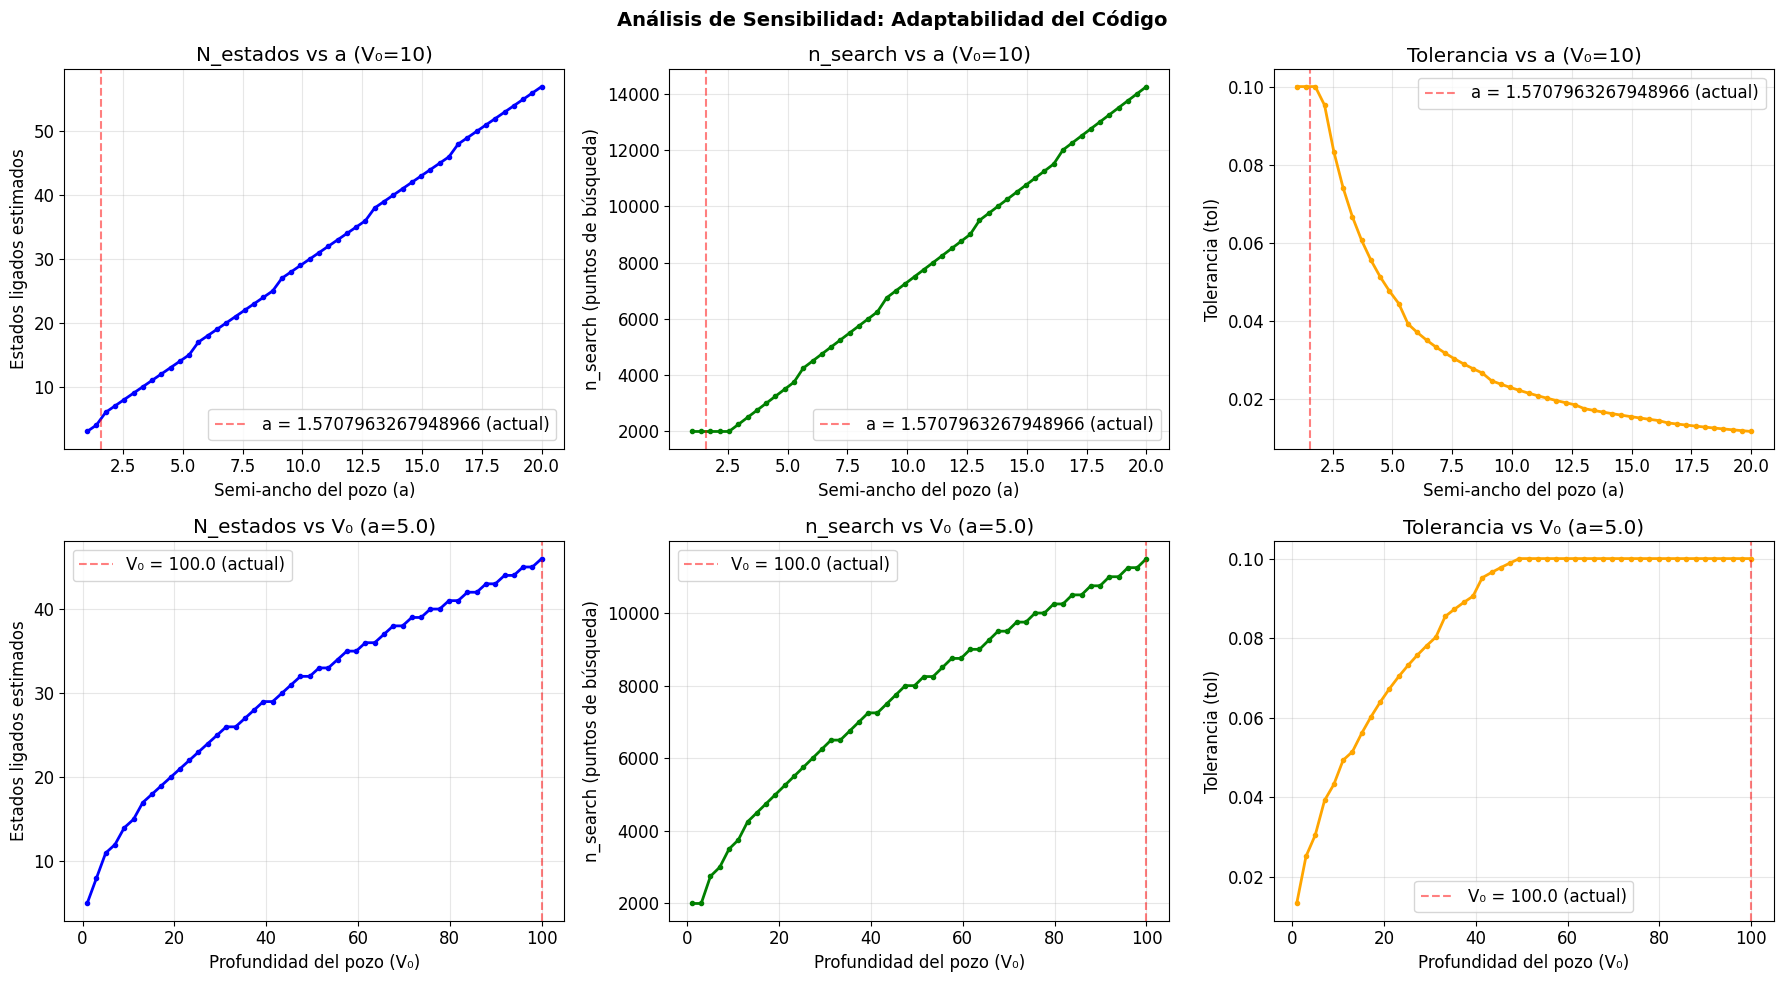


RELACIÓN ENTRE PARÁMETROS:

1. Número de estados ∝ √(V₀) × a
   - Aumentar V₀: +√V₀ estados
   - Aumentar a: +a estados

2. Puntos de búsqueda (n_search) ∝ N_estados × 250
   - Se ajusta automáticamente para mantener precisión

3. Tolerancia ∝ V₀ / N_estados
   - Más estricta con muchos estados (menos espacio entre ellos)
   - Menos estricta con pocos estados


In [5]:
# Análisis de sensibilidad: cómo varían N_estados, n_search, tol con a y V0
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Rango de variación de parámetros
a_values = np.linspace(1, 20, 50)
V0_values = np.linspace(1, 100, 50)

# 1. Variación con a (fijando V0 = 10)
V0_fixed = 10.0
n_states_vs_a = []
n_search_vs_a = []
tol_vs_a = []
for a_val in a_values:
    p = estimate_and_optimize_parameters(a_val, V0_fixed, hbar, m)
    n_states_vs_a.append(p['N_states_estimated'])
    n_search_vs_a.append(p['n_search'])
    tol_vs_a.append(p['tolerance'])

ax = axes[0, 0]
ax.plot(a_values, n_states_vs_a, 'b-', linewidth=2, marker='o', markersize=3)
ax.axvline(x=a, color='r', linestyle='--', alpha=0.5, label=f'a = {a} (actual)')
ax.set_xlabel('Semi-ancho del pozo (a)')
ax.set_ylabel('Estados ligados estimados')
ax.set_title('N_estados vs a (V₀=10)')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[0, 1]
ax.plot(a_values, n_search_vs_a, 'g-', linewidth=2, marker='o', markersize=3)
ax.axvline(x=a, color='r', linestyle='--', alpha=0.5, label=f'a = {a} (actual)')
ax.set_xlabel('Semi-ancho del pozo (a)')
ax.set_ylabel('n_search (puntos de búsqueda)')
ax.set_title('n_search vs a (V₀=10)')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[0, 2]
ax.plot(a_values, tol_vs_a, 'orange', linewidth=2, marker='o', markersize=3)
ax.axvline(x=a, color='r', linestyle='--', alpha=0.5, label=f'a = {a} (actual)')
ax.set_xlabel('Semi-ancho del pozo (a)')
ax.set_ylabel('Tolerancia (tol)')
ax.set_title('Tolerancia vs a (V₀=10)')
ax.grid(True, alpha=0.3)
ax.legend()

# 2. Variación con V0 (fijando a = 5)
a_fixed = 5.0
n_states_vs_V0 = []
n_search_vs_V0 = []
tol_vs_V0 = []
for V0_val in V0_values:
    p = estimate_and_optimize_parameters(a_fixed, V0_val, hbar, m)
    n_states_vs_V0.append(p['N_states_estimated'])
    n_search_vs_V0.append(p['n_search'])
    tol_vs_V0.append(p['tolerance'])

ax = axes[1, 0]
ax.plot(V0_values, n_states_vs_V0, 'b-', linewidth=2, marker='o', markersize=3)
ax.axvline(x=V0, color='r', linestyle='--', alpha=0.5, label=f'V₀ = {V0} (actual)')
ax.set_xlabel('Profundidad del pozo (V₀)')
ax.set_ylabel('Estados ligados estimados')
ax.set_title(f'N_estados vs V₀ (a={a_fixed})')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 1]
ax.plot(V0_values, n_search_vs_V0, 'g-', linewidth=2, marker='o', markersize=3)
ax.axvline(x=V0, color='r', linestyle='--', alpha=0.5, label=f'V₀ = {V0} (actual)')
ax.set_xlabel('Profundidad del pozo (V₀)')
ax.set_ylabel('n_search (puntos de búsqueda)')
ax.set_title(f'n_search vs V₀ (a={a_fixed})')
ax.grid(True, alpha=0.3)
ax.legend()

ax = axes[1, 2]
ax.plot(V0_values, tol_vs_V0, 'orange', linewidth=2, marker='o', markersize=3)
ax.axvline(x=V0, color='r', linestyle='--', alpha=0.5, label=f'V₀ = {V0} (actual)')
ax.set_xlabel('Profundidad del pozo (V₀)')
ax.set_ylabel('Tolerancia (tol)')
ax.set_title(f'Tolerancia vs V₀ (a={a_fixed})')
ax.grid(True, alpha=0.3)
ax.legend()

plt.suptitle('Análisis de Sensibilidad: Adaptabilidad del Código', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("RELACIÓN ENTRE PARÁMETROS:")
print("="*70)
print("\n1. Número de estados ∝ √(V₀) × a")
print("   - Aumentar V₀: +√V₀ estados")
print("   - Aumentar a: +a estados")
print("\n2. Puntos de búsqueda (n_search) ∝ N_estados × 250")
print("   - Se ajusta automáticamente para mantener precisión")
print("\n3. Tolerancia ∝ V₀ / N_estados")
print("   - Más estricta con muchos estados (menos espacio entre ellos)")
print("   - Menos estricta con pocos estados")
print("="*70)

## 4. Búsqueda de Autovalores de Energía

Para encontrar los autovalores, usamos el **método del disparo bilateral** (*bilateral shooting method*):

1. Integramos la ecuación desde la izquierda hacia el centro
2. Integramos desde la derecha hacia el centro
3. Buscamos energías donde la derivada sea continua en el punto de matching

Esto garantiza que la función de onda se hace cero en ambos extremos (∞ y -∞).

In [6]:
def find_eigenvalues(x, V, E_min, E_max, n_search=1000, hbar=1.0, m=1.0, tol=1e-3):
    """
    Encuentra autovalores de energía en el rango [E_min, E_max].
    
    MEJORADO: Rechaza estados espurios después de que Brent's method encuentra
    un "cero". Valida que la solución tenga amplitudes físicamente razonables.
    """
    E_test = np.linspace(E_min, E_max, n_search)
    bc_values = np.array([boundary_condition(E, x, V, hbar, m) for E in E_test])
    
    eigenvalues = []
    for i in range(len(bc_values) - 1):
        if bc_values[i] * bc_values[i+1] < 0:  # Cambio de signo
            try:
                E_eigen = optimize.brentq(boundary_condition, E_test[i], E_test[i+1], 
                                         args=(x, V, hbar, m))
                
                # === VALIDACIÓN ADICIONAL después de encontrar el "cero" ===
                # Verificar que es un cero REAL, no un false zero
                _, psi_L, psi_R, n_match = solve_schrodinger(x, V, E_eigen, hbar, m)
                
                amp_L = np.max(np.abs(psi_L[1:n_match+1]))
                amp_R = np.max(np.abs(psi_R[n_match:-1]))
                
                # RECHAZO si hay debalance grave
                if min(amp_L, amp_R) > 1e-15:
                    ratio = max(amp_L, amp_R) / min(amp_L, amp_R)
                    if ratio > 1e5:  # Debalance inaceptable
                        continue  # Saltar este "eigenvalor" espurio
                
                # RECHAZO si amplitudes son minúsculas
                if amp_L < 1e-12 or amp_R < 1e-12:
                    continue
                
                # Si pasó las validaciones, verificar que no es duplicado
                is_duplicate = False
                for E_prev in eigenvalues:
                    if abs(E_eigen - E_prev) < tol:
                        is_duplicate = True
                        break
                
                if not is_duplicate:
                    eigenvalues.append(E_eigen)
            except:
                pass
    
    return np.array(eigenvalues), E_test, bc_values

In [7]:
def solve_schrodinger(x, V, E, hbar=1.0, m=1.0):
    """
    Resuelve la ecuación de Schrödinger usando shooting desde ambos lados.
    
    Versión MEJORADA que detecta y rechaza "falsos ceros" causados por 
    amplitudes desbalanceadas entre izquierda y derecha.
    
    Retorna: (psi, psi_left, psi_right, n_match)
    """
    n = len(x)
    h = x[1] - x[0]
    n_match = n // 2
    
    # === Calcular coeficientes de Numerov ===
    g = 2.0 * m * (E - V) / hbar**2
    c0 = 1.0 + h**2 * g / 12.0
    c1 = 2.0 * (1.0 - 5.0 * h**2 * g / 12.0)
    
    # === Integración desde la izquierda ===
    psi_left = np.zeros(n)
    psi_left[0] = 0.0
    psi_left[1] = 1e-10
    
    for i in range(1, n_match):
        psi_left[i+1] = (c1[i] * psi_left[i] - c0[i-1] * psi_left[i-1]) / c0[i+1]
    
    # === Integración desde la derecha ===
    psi_right = np.zeros(n)
    psi_right[-1] = 0.0
    psi_right[-2] = 1e-10
    
    for i in range(n-2, n_match, -1):
        psi_right[i-1] = (c1[i] * psi_right[i] - c0[i+1] * psi_right[i+1]) / c0[i-1]
    
    # === Matching con CONTROL DE AMPLITUDES ===
    psi_L_match = psi_left[n_match]
    psi_R_match = psi_right[n_match]
    
    # Si alguno es nulo, no hay solución válida
    if abs(psi_L_match) < 1e-15 or abs(psi_R_match) < 1e-15:
        return np.zeros(n), psi_left, psi_right, n_match
    
    # Amplitudes máximas (excluyendo fronteras)
    amp_L = np.max(np.abs(psi_left[1:n_match+1]))
    amp_R = np.max(np.abs(psi_right[n_match:-1]))
    
    # CONTROL CRÍTICO: Si las amplitudes están muy desbalanceadas,
    # es un "falso cero" - rechazar escalando psi_right a cero
    if min(amp_L, amp_R) > 1e-15:
        ratio = max(amp_L, amp_R) / min(amp_L, amp_R)
        # Si ratio > 1e6, hay overflow numérico inminente
        if ratio > 1e6:
            return np.zeros(n), psi_left, psi_right, n_match
    
    # Si alguna amplitud es prácticamente cero
    if amp_L < 1e-12 or amp_R < 1e-12:
        return np.zeros(n), psi_left, psi_right, n_match
    
    # SCALING SEGURO: Normalizar ambas soluciones ANTES de matching
    scale_L = 1.0 / amp_L if amp_L > 1e-15 else 1.0
    scale_R = 1.0 / amp_R if amp_R > 1e-15 else 1.0
    
    psi_left_norm = psi_left * scale_L
    psi_right_norm = psi_right * scale_R
    
    # Ahora hacer matching con soluciones normalizadas
    scale_factor = psi_left_norm[n_match] / psi_right_norm[n_match]
    psi_right_scaled = psi_right_norm * scale_factor
    
    # Combinar
    psi = np.concatenate([psi_left_norm[:n_match+1], psi_right_scaled[n_match+1:]])
    
    # Retornar soluciones NORMALIZADAS
    return psi, psi_left_norm, psi_right_scaled, n_match


def boundary_condition(E, x, V, hbar=1.0, m=1.0):
    """
    Función objetivo para encontrar autovalores.
    
    Retorna la discontinuidad en la derivada logarítmica en el matching.
    IMPORTANTE: Rechaza "falsos ceros" donde las soluciones son inestables.
    """
    psi, psi_left, psi_right, n_match = solve_schrodinger(x, V, E, hbar, m)
    h = x[1] - x[0]
    n = len(x)
    
    # === FILTRO 1: Si psi es nulo en todas partes, rechazar ===
    if np.max(np.abs(psi)) < 1e-14:
        return 1.0
    
    psi_c = psi[n_match]
    if abs(psi_c) < 1e-14:
        return 1.0
    
    # === FILTRO 2: Detectar debalances graves ===
    amp_L = np.max(np.abs(psi_left[1:n_match+1]))
    amp_R = np.max(np.abs(psi_right[n_match:-1]))
    
    # Si ambas amplitudes son muy pequeñas
    if amp_L < 1e-12 and amp_R < 1e-12:
        return 1.0
    
    # Si una amplitud es minúscula comparada con la otra
    if min(amp_L, amp_R) > 1e-15:
        ratio = max(amp_L, amp_R) / min(amp_L, amp_R)
        # Si ratio > 1e5, hay problemas numéricos
        if ratio > 1e5:
            return 1.0
    
    # === FILTRO 3: Verificar derivadas ===
    if n_match > 1 and n_match < n - 2:
        dpsi_c = (psi[n_match+1] - psi[n_match-1]) / (2.0 * h)
    else:
        dpsi_c = 0.0
    
    log_deriv = dpsi_c / psi_c if abs(psi_c) > 1e-15 else 0.0
    
    # Derivada desde la izquierda
    if n_match > 0 and abs(psi_left[n_match]) > 1e-15:
        dpsi_L = (psi_left[n_match] - psi_left[n_match-1]) / h
        log_deriv_L = dpsi_L / psi_left[n_match]
    else:
        log_deriv_L = 0.0
    
    # Derivada desde la derecha
    if n_match < n - 1 and abs(psi_right[n_match]) > 1e-15:
        dpsi_R = (psi_right[n_match+1] - psi_right[n_match]) / h
        log_deriv_R = dpsi_R / psi_right[n_match]
    else:
        log_deriv_R = 0.0
    
    # === FILTRO 4: Si la discontinuidad es absurda, rechazar ===
    discontinuity = log_deriv_L - log_deriv_R
    if abs(discontinuity) > 1e10:
        return 1.0
    
    return discontinuity

Buscando autovalores de energía (con parámetros adaptables)...
  Buscando en: 3750 puntos
  Tolerancia: 0.100000


Autovalores de energía encontrados (estados ligados):
  Total encontrados: 14 (estimados: 15)
  E_0 = 0.459624
  E_1 = 4.134396
  E_2 = 7.287192
  E_3 = 11.471453
  E_4 = 16.372624
  E_5 = 22.442383
  E_6 = 29.041360
  E_7 = 36.993178
  E_8 = 45.220939
  E_9 = 55.017569
  E_10 = 64.758334
  E_11 = 76.258917
  E_12 = 87.193363
  E_13 = 99.215148


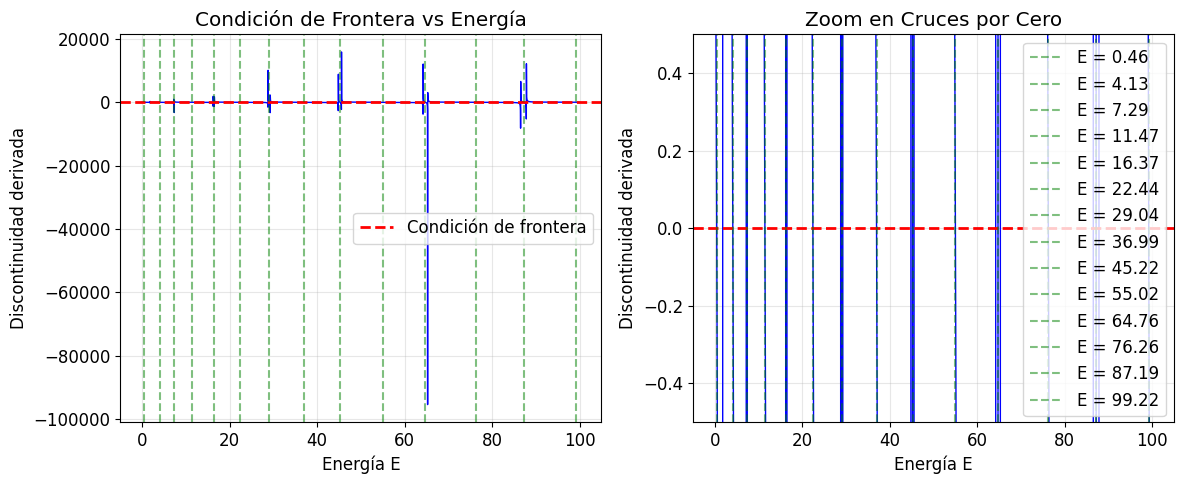

In [8]:
# Buscar autovalores en el rango [0, V0) usando parámetros adaptables
print("Buscando autovalores de energía (con parámetros adaptables)...")
print(f"  Buscando en: {params['n_search']} puntos")
print(f"  Tolerancia: {params['tolerance']:.6f}\n")

E_min = 0.01
E_max = V0 - 0.01
eigenvalues, E_test, bc_values = find_eigenvalues(
    x, V, E_min, E_max, 
    n_search=params['n_search'], 
    hbar=hbar, m=m, 
    tol=params['tolerance']
)

print(f"\nAutovalores de energía encontrados (estados ligados):")
print(f"  Total encontrados: {len(eigenvalues)} (estimados: {params['N_states_estimated']})")
for i, E in enumerate(eigenvalues):
    print(f"  E_{i} = {E:.6f}")

# Visualizar la función de condición de frontera
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(E_test, bc_values, 'b-', linewidth=1)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Condición de frontera')
for E in eigenvalues:
    plt.axvline(x=E, color='g', linestyle='--', alpha=0.5)
plt.xlabel('Energía E')
plt.ylabel('Discontinuidad derivada')
plt.title('Condición de Frontera vs Energía')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(E_test, bc_values, 'b-', linewidth=1)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
for E in eigenvalues:
    plt.axvline(x=E, color='g', linestyle='--', alpha=0.5, label=f'E = {E:.2f}')
plt.xlabel('Energía E')
plt.ylabel('Discontinuidad derivada')
plt.title('Zoom en Cruces por Cero')
plt.ylim(-0.5, 0.5)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Calcular Autofunciones y Normalizar

Para cada autovalor de energía, calculamos la autofunción correspondiente y la normalizamos.

In [9]:
def normalize_wavefunction(x, psi):
    """
    Normaliza la función de onda.
    
    Retorna:
    --------
    psi_norm : array
        Función de onda normalizada tal que ∫|ψ|² dx = 1
    """
    # Calcular la integral de |psi|^2
    norm = simpson(np.abs(psi)**2, x=x)
    
    # Normalizar
    psi_norm = psi / np.sqrt(norm)
    
    return psi_norm

# Calcular y normalizar autofunciones
eigenfunctions = []
probability_densities = []

print("Calculando autofunciones...")
for i, E in enumerate(eigenvalues):
    psi, _, _, _ = solve_schrodinger(x, V, E, hbar, m)
    psi_norm = normalize_wavefunction(x, psi)
    eigenfunctions.append(psi_norm)
    
    # Calcular densidad de probabilidad
    rho = np.abs(psi_norm)**2
    probability_densities.append(rho)
    
    # Verificar normalización
    integral = simpson(rho, x=x)
    print(f"  Estado {i}: E = {E:.6f}, ∫|ψ|² dx = {integral:.6f}")

eigenfunctions = np.array(eigenfunctions)
probability_densities = np.array(probability_densities)

Calculando autofunciones...
  Estado 0: E = 0.459624, ∫|ψ|² dx = 1.000000
  Estado 1: E = 4.134396, ∫|ψ|² dx = 1.000000
  Estado 2: E = 7.287192, ∫|ψ|² dx = 1.000000
  Estado 3: E = 11.471453, ∫|ψ|² dx = 1.000000
  Estado 4: E = 16.372624, ∫|ψ|² dx = 1.000000
  Estado 5: E = 22.442383, ∫|ψ|² dx = 1.000000
  Estado 6: E = 29.041360, ∫|ψ|² dx = 1.000000
  Estado 7: E = 36.993178, ∫|ψ|² dx = 1.000000
  Estado 8: E = 45.220939, ∫|ψ|² dx = 1.000000
  Estado 9: E = 55.017569, ∫|ψ|² dx = 1.000000
  Estado 10: E = 64.758334, ∫|ψ|² dx = 1.000000
  Estado 11: E = 76.258917, ∫|ψ|² dx = 1.000000
  Estado 12: E = 87.193363, ∫|ψ|² dx = 1.000000
  Estado 13: E = 99.215148, ∫|ψ|² dx = 1.000000


In [10]:
# Verificar que las funciones de onda se hacen cero en los extremos
print("\nVerificación de condiciones de frontera:")
print("=" * 70)
for i in range(min(10, len(eigenfunctions))):  # Primeros 10 estados
    psi = eigenfunctions[i]
    E = eigenvalues[i]
    val_left = abs(psi[0])
    val_right = abs(psi[-1])
    val_center = abs(psi[len(psi)//2])
    print(f"Estado {i}: E={E:.4f}, |ψ(x_min)|={val_left:.2e}, |ψ(x_max)|={val_right:.2e}, |ψ(centro)|={val_center:.2e}")


Verificación de condiciones de frontera:
Estado 0: E=0.4596, |ψ(x_min)|=0.00e+00, |ψ(x_max)|=0.00e+00, |ψ(centro)|=7.78e-01
Estado 1: E=4.1344, |ψ(x_min)|=0.00e+00, |ψ(x_max)|=0.00e+00, |ψ(centro)|=7.77e-01
Estado 2: E=7.2872, |ψ(x_min)|=0.00e+00, |ψ(x_max)|=0.00e+00, |ψ(centro)|=1.98e-02
Estado 3: E=11.4715, |ψ(x_min)|=0.00e+00, |ψ(x_max)|=0.00e+00, |ψ(centro)|=7.76e-01
Estado 4: E=16.3726, |ψ(x_min)|=0.00e+00, |ψ(x_max)|=0.00e+00, |ψ(centro)|=2.97e-02
Estado 5: E=22.4424, |ψ(x_min)|=0.00e+00, |ψ(x_max)|=0.00e+00, |ψ(centro)|=7.74e-01
Estado 6: E=29.0414, |ψ(x_min)|=0.00e+00, |ψ(x_max)|=0.00e+00, |ψ(centro)|=3.95e-02
Estado 7: E=36.9932, |ψ(x_min)|=0.00e+00, |ψ(x_max)|=0.00e+00, |ψ(centro)|=7.71e-01
Estado 8: E=45.2209, |ψ(x_min)|=0.00e+00, |ψ(x_max)|=0.00e+00, |ψ(centro)|=4.91e-02
Estado 9: E=55.0176, |ψ(x_min)|=0.00e+00, |ψ(x_max)|=0.00e+00, |ψ(centro)|=7.66e-01


## 6. Visualización de Resultados

Visualizamos el potencial, los niveles de energía, las autofunciones y las densidades de probabilidad.

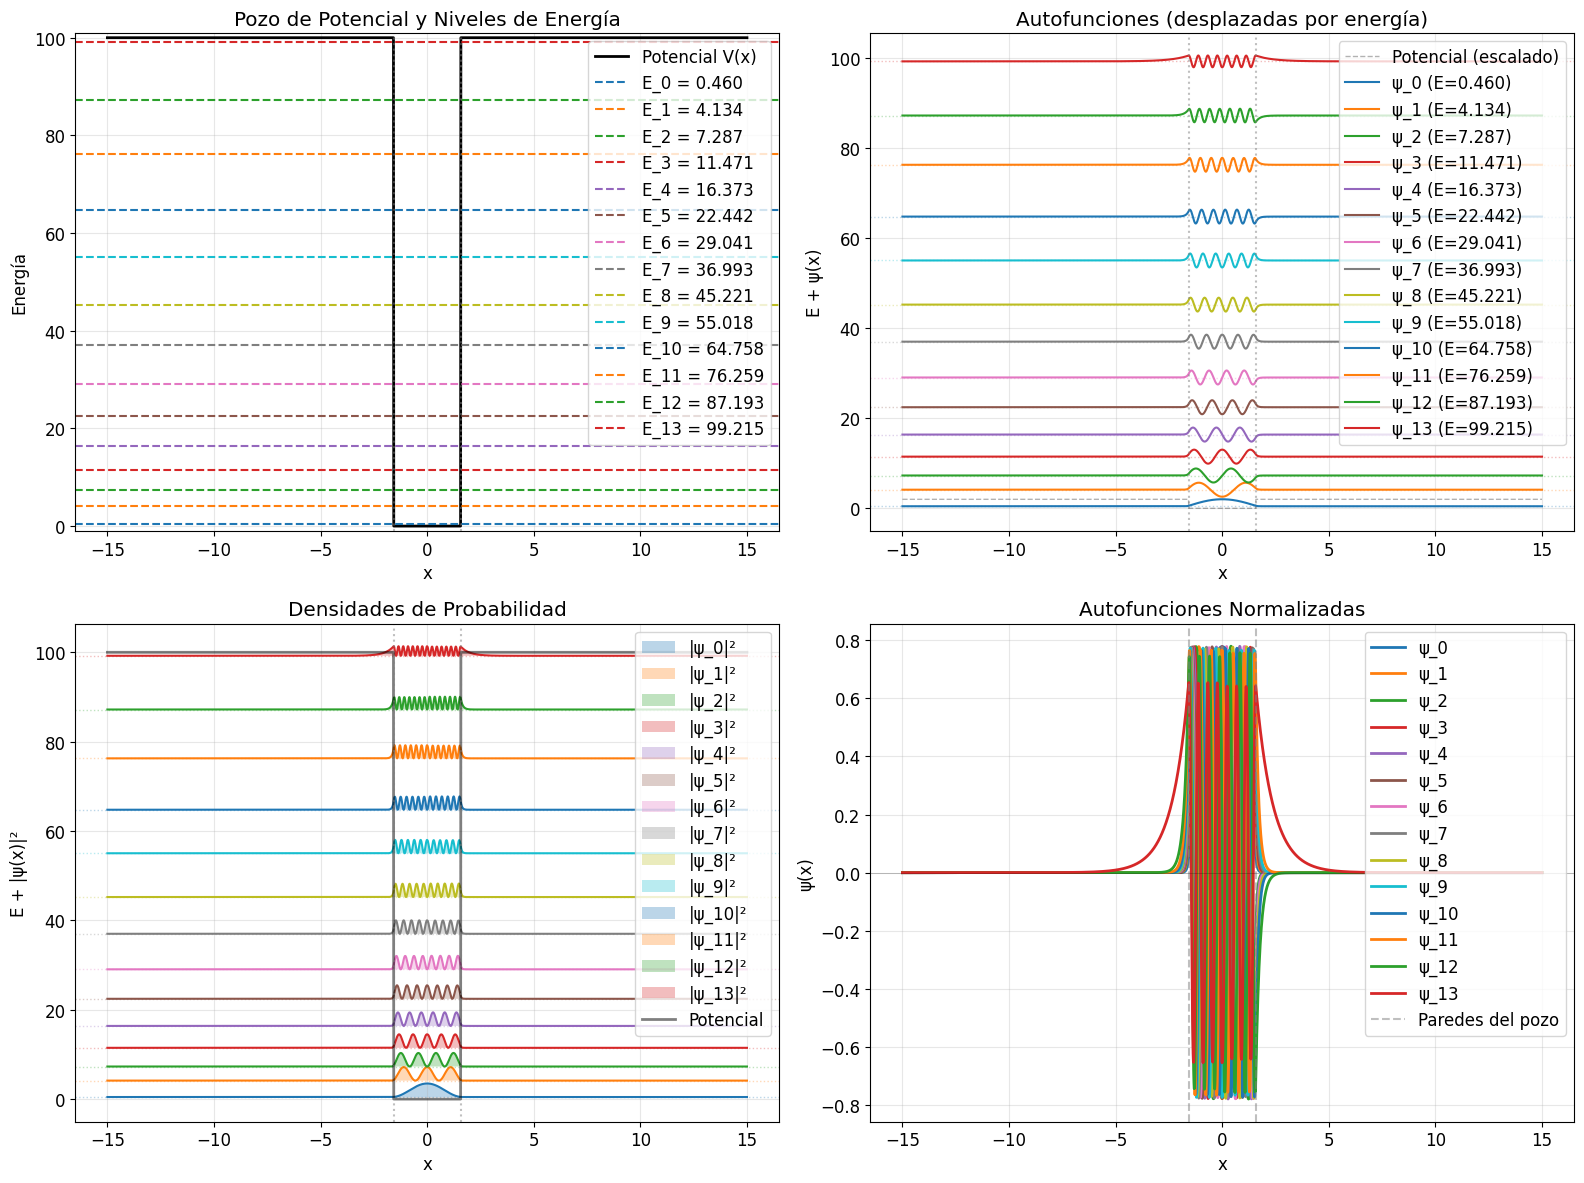

In [11]:
# Visualización completa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Potencial y niveles de energía
ax = axes[0, 0]
ax.plot(x, V, 'k-', linewidth=2, label='Potencial V(x)')
for i, E in enumerate(eigenvalues):
    ax.axhline(y=E, color=f'C{i}', linestyle='--', linewidth=1.5, 
               label=f'E_{i} = {E:.3f}')
ax.axvline(x=-a, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=a, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('Energía')
ax.set_title('Pozo de Potencial y Niveles de Energía')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-1, V0 + 1)

# 2. Autofunciones
ax = axes[0, 1]
ax.plot(x, V/V0 * 2, 'k--', linewidth=1, alpha=0.3, label='Potencial (escalado)')
for i, (E, psi) in enumerate(zip(eigenvalues, eigenfunctions)):
    # Desplazar cada función de onda a su nivel de energía
    offset = E
    scale = 2.0  # Factor de escala para visualización
    ax.plot(x, offset + scale * psi, label=f'ψ_{i} (E={E:.3f})', linewidth=1.5)
    ax.axhline(y=E, color=f'C{i}', linestyle=':', alpha=0.3, linewidth=1)
ax.axvline(x=-a, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=a, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('E + ψ(x)')
ax.set_title('Autofunciones (desplazadas por energía)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# 3. Densidades de probabilidad
ax = axes[1, 0]
for i, (E, rho) in enumerate(zip(eigenvalues, probability_densities)):
    offset = E
    scale = 5.0  # Factor de escala para visualización
    ax.fill_between(x, offset, offset + scale * rho, alpha=0.3, label=f'|ψ_{i}|²')
    ax.plot(x, offset + scale * rho, linewidth=1.5, color=f'C{i}')
    ax.axhline(y=E, color=f'C{i}', linestyle=':', alpha=0.3, linewidth=1)
ax.plot(x, V, 'k-', linewidth=2, alpha=0.5, label='Potencial')
ax.axvline(x=-a, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=a, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('E + |ψ(x)|²')
ax.set_title('Densidades de Probabilidad')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# 4. Detalle de las funciones de onda sin desplazamiento
ax = axes[1, 1]
for i, psi in enumerate(eigenfunctions):
    ax.plot(x, psi, label=f'ψ_{i}', linewidth=2)
ax.axvline(x=-a, color='gray', linestyle='--', alpha=0.5, label='Paredes del pozo')
ax.axvline(x=a, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('ψ(x)')
ax.set_title('Autofunciones Normalizadas')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

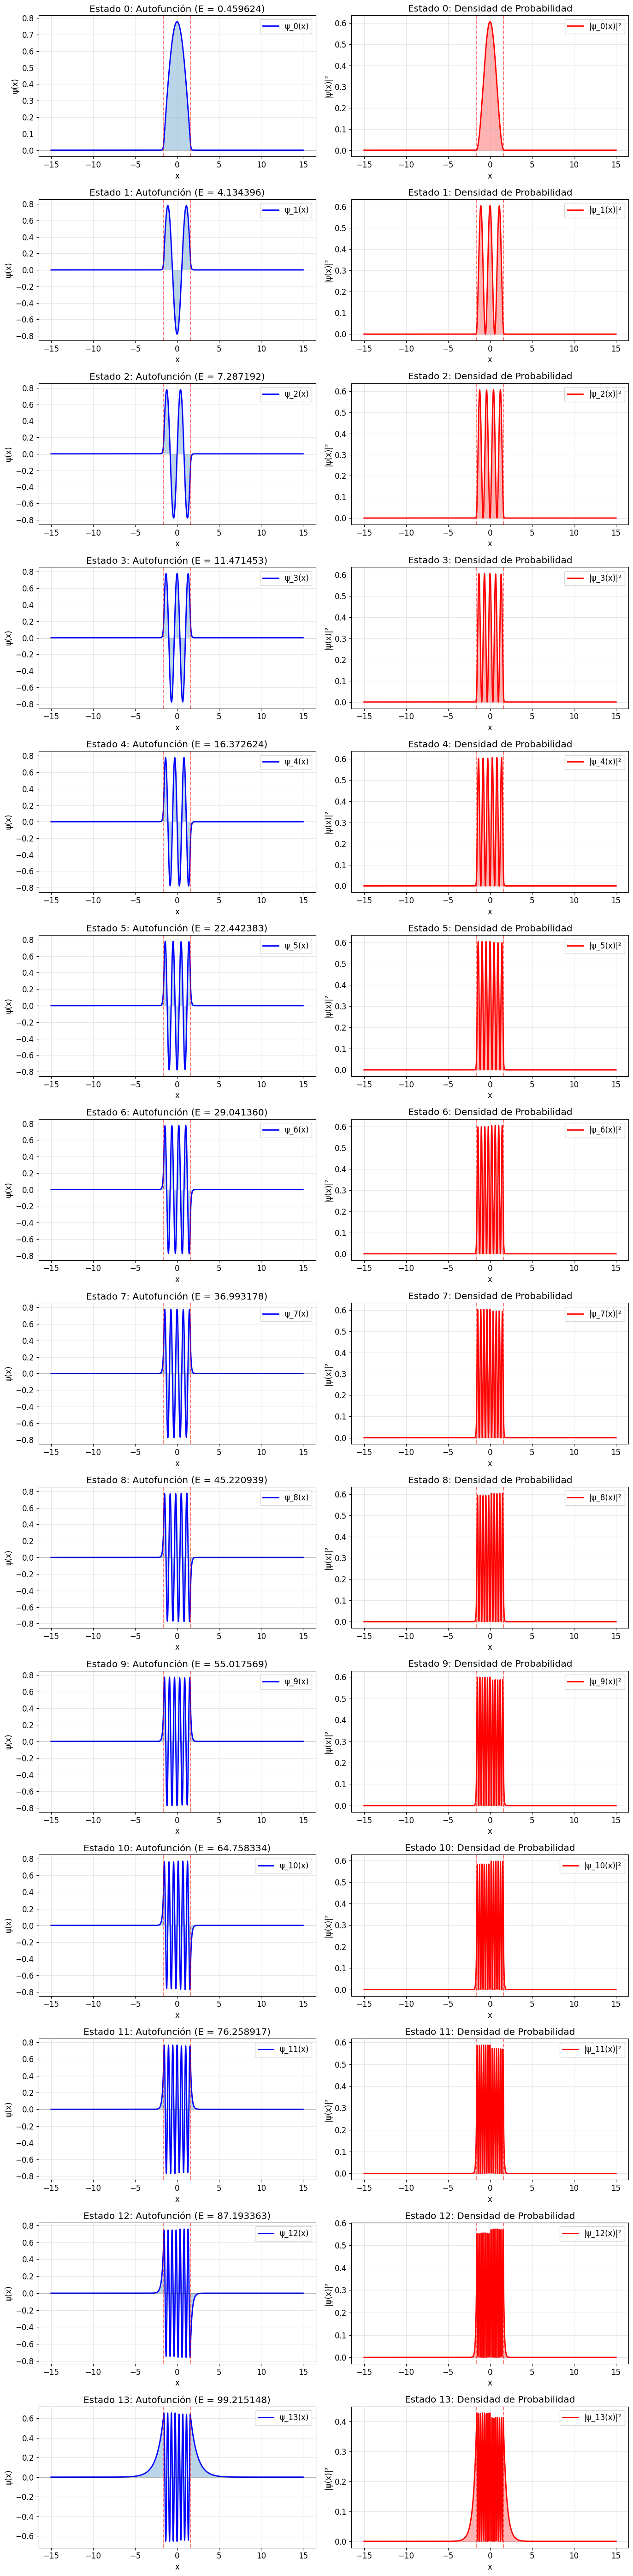

In [12]:
# Gráficos individuales de cada estado
n_states = len(eigenvalues)
fig, axes = plt.subplots(n_states, 2, figsize=(14, 4*n_states))

if n_states == 1:
    axes = axes.reshape(1, -1)

for i, (E, psi, rho) in enumerate(zip(eigenvalues, eigenfunctions, probability_densities)):
    # Autofunción
    ax = axes[i, 0]
    ax.plot(x, psi, 'b-', linewidth=2, label=f'ψ_{i}(x)')
    ax.axvline(x=-a, color='r', linestyle='--', alpha=0.5)
    ax.axvline(x=a, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
    ax.fill_between(x, 0, psi, alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel('ψ(x)')
    ax.set_title(f'Estado {i}: Autofunción (E = {E:.6f})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Densidad de probabilidad
    ax = axes[i, 1]
    ax.plot(x, rho, 'r-', linewidth=2, label=f'|ψ_{i}(x)|²')
    ax.axvline(x=-a, color='r', linestyle='--', alpha=0.5)
    ax.axvline(x=a, color='r', linestyle='--', alpha=0.5)
    ax.fill_between(x, 0, rho, alpha=0.3, color='red')
    ax.set_xlabel('x')
    ax.set_ylabel('|ψ(x)|²')
    ax.set_title(f'Estado {i}: Densidad de Probabilidad')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Análisis y Propiedades

Calculamos algunas propiedades importantes de los estados encontrados.

In [13]:
print("=" * 70)
print("ANÁLISIS DE LOS ESTADOS LIGADOS")
print("=" * 70)

for i, (E, psi, rho) in enumerate(zip(eigenvalues, eigenfunctions, probability_densities)):
    print(f"\nEstado {i}:")
    print(f"  Energía: E_{i} = {E:.8f}")
    print(f"  Energía de ligadura: |E_{i}| = {abs(E):.8f}")
    
    # Valor esperado de la posición
    x_mean = simpson(x * rho, x=x)
    print(f"  ⟨x⟩ = {x_mean:.8f}")
    
    # Valor esperado de x²
    x2_mean = simpson(x**2 * rho, x=x)
    print(f"  ⟨x²⟩ = {x2_mean:.8f}")
    
    # Desviación estándar de la posición
    sigma_x = np.sqrt(x2_mean - x_mean**2)
    print(f"  σ_x = {sigma_x:.8f}")
    
    # Probabilidad de encontrar la partícula dentro del pozo
    mask_inside = np.abs(x) < a
    prob_inside = simpson(rho[mask_inside], x=x[mask_inside])
    print(f"  Probabilidad dentro del pozo: {prob_inside:.6f} ({prob_inside*100:.2f}%)")
    
    # Nodos (cambios de signo en la función de onda)
    sign_changes = np.where(np.diff(np.sign(psi)))[0]
    n_nodes = len(sign_changes)
    print(f"  Número de nodos: {n_nodes}")

print("\n" + "=" * 70)

ANÁLISIS DE LOS ESTADOS LIGADOS

Estado 0:
  Energía: E_0 = 0.45962438
  Energía de ligadura: |E_0| = 0.45962438
  ⟨x⟩ = -0.00004030
  ⟨x²⟩ = 0.35460490
  σ_x = 0.59548711
  Probabilidad dentro del pozo: 0.999762 (99.98%)
  Número de nodos: 2

Estado 1:
  Energía: E_1 = 4.13439554
  Energía de ligadura: |E_1| = 4.13439554
  ⟨x⟩ = -0.00057826
  ⟨x²⟩ = 0.83952491
  σ_x = 0.91625574
  Probabilidad dentro del pozo: 0.997826 (99.78%)
  Número de nodos: 4

Estado 2:
  Energía: E_2 = 7.28719212
  Energía de ligadura: |E_2| = 7.28719212
  ⟨x⟩ = 0.00106437
  ⟨x²⟩ = 0.87065969
  σ_x = 0.93309086
  Probabilidad dentro del pozo: 0.996095 (99.61%)
  Número de nodos: 5

Estado 3:
  Energía: E_3 = 11.47145335
  Energía de ligadura: |E_3| = 11.47145335
  ⟨x⟩ = -0.00165489
  ⟨x²⟩ = 0.88140038
  σ_x = 0.93882780
  Probabilidad dentro del pozo: 0.993780 (99.38%)
  Número de nodos: 6

Estado 4:
  Energía: E_4 = 16.37262367
  Energía de ligadura: |E_4| = 16.37262367
  ⟨x⟩ = 0.00239636
  ⟨x²⟩ = 0.89394734
 

## 8. Comparación con Solución Analítica (Estimación)

Para un pozo infinito de ancho $2a$, las energías son:

$$E_n^{\text{infinito}} = \frac{n^2 \pi^2 \hbar^2}{2m(2a)^2} = \frac{n^2 \pi^2}{8ma^2}$$

Para un pozo finito, las energías son menores y dependen de la profundidad del pozo. Comparamos con el límite del pozo infinito.

In [14]:
# Comparación con pozo infinito
print("Comparación con Pozo Infinito de ancho 2a:")
print("=" * 70)

for i, E in enumerate(eigenvalues):
    n = i + 1
    # Energía para pozo infinito (en unidades atómicas)
    E_infinite = (n * np.pi)**2 / (8 * m * a**2) * hbar**2
    
    # Diferencia relativa
    diff = (E_infinite - E) / E_infinite * 100
    
    print(f"\nEstado n={n}:")
    print(f"  E_numérico    = {E:.8f}")
    print(f"  E_infinito    = {E_infinite:.8f}")
    print(f"  Diferencia    = {E_infinite - E:.8f}")
    print(f"  Diff relativa = {diff:.2f}%")

print("\n" + "=" * 70)
print("Nota: El pozo finito tiene energías menores que el pozo infinito")
print("      debido a la penetración de la función de onda en las barreras.")

Comparación con Pozo Infinito de ancho 2a:

Estado n=1:
  E_numérico    = 0.45962438
  E_infinito    = 0.50000000
  Diferencia    = 0.04037562
  Diff relativa = 8.08%

Estado n=2:
  E_numérico    = 4.13439554
  E_infinito    = 2.00000000
  Diferencia    = -2.13439554
  Diff relativa = -106.72%

Estado n=3:
  E_numérico    = 7.28719212
  E_infinito    = 4.50000000
  Diferencia    = -2.78719212
  Diff relativa = -61.94%

Estado n=4:
  E_numérico    = 11.47145335
  E_infinito    = 8.00000000
  Diferencia    = -3.47145335
  Diff relativa = -43.39%

Estado n=5:
  E_numérico    = 16.37262367
  E_infinito    = 12.50000000
  Diferencia    = -3.87262367
  Diff relativa = -30.98%

Estado n=6:
  E_numérico    = 22.44238253
  E_infinito    = 18.00000000
  Diferencia    = -4.44238253
  Diff relativa = -24.68%

Estado n=7:
  E_numérico    = 29.04135998
  E_infinito    = 24.50000000
  Diferencia    = -4.54135998
  Diff relativa = -18.54%

Estado n=8:
  E_numérico    = 36.99317804
  E_infinito    = 32

## 9. Ejemplo con Potencial Arbitrario: Oscilador Armónico

Ahora probamos el solver con un potencial diferente: el oscilador armónico cuántico.

$$V(x) = \frac{1}{2}m\omega^2 x^2$$

Las energías analíticas son: $E_n = \hbar\omega(n + \frac{1}{2})$

Resolviendo oscilador armónico cuántico...

Comparación con solución analítica:
n=0: E_numérico = 0.503781, E_analítico = 0.500000, Error = 0.7562%
n=1: E_numérico = 1.500001, E_analítico = 1.500000, Error = 0.0001%
n=2: E_numérico = 2.509423, E_analítico = 2.500000, Error = 0.3769%
n=3: E_numérico = 3.500004, E_analítico = 3.500000, Error = 0.0001%
n=4: E_numérico = 4.512713, E_analítico = 4.500000, Error = 0.2825%


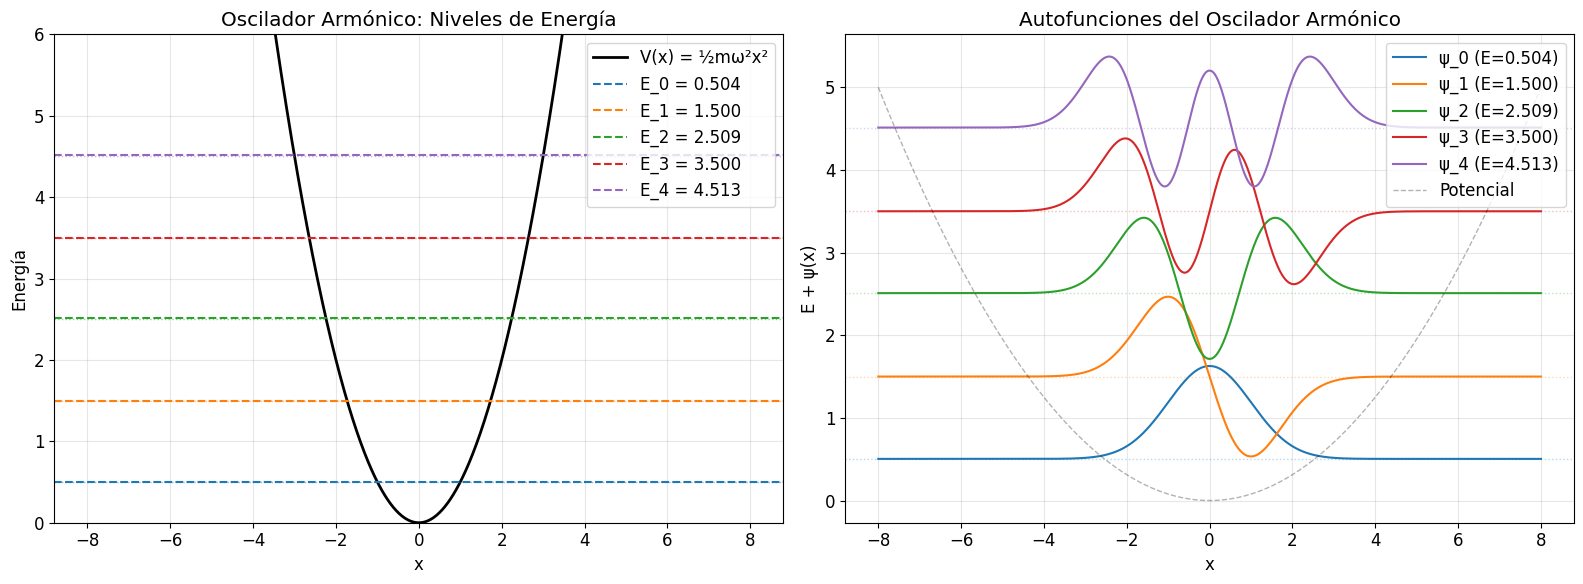

In [15]:
# Potencial del oscilador armónico
omega = 1.0  # Frecuencia angular
V_ho = 0.5 * m * omega**2 * x**2

# Buscar autovalores
print("Resolviendo oscilador armónico cuántico...")
E_min_ho = 0.1
E_max_ho = 10.0
eigenvalues_ho, _, _ = find_eigenvalues(x, V_ho, E_min_ho, E_max_ho, n_search=2000, hbar=hbar, m=m, tol=0.1)

# Calcular autofunciones
eigenfunctions_ho = []
for E in eigenvalues_ho[:5]:  # Solo los primeros 5 estados
    psi, _, _, _ = solve_schrodinger(x, V_ho, E, hbar, m)
    psi_norm = normalize_wavefunction(x, psi)
    eigenfunctions_ho.append(psi_norm)

# Comparar con solución analítica
print("\nComparación con solución analítica:")
print("=" * 70)
for i, E in enumerate(eigenvalues_ho[:5]):
    E_analytical = hbar * omega * (i + 0.5)
    error = abs(E - E_analytical) / E_analytical * 100
    print(f"n={i}: E_numérico = {E:.6f}, E_analítico = {E_analytical:.6f}, Error = {error:.4f}%")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Potencial y niveles
ax = axes[0]
x_plot = x[np.abs(x) < 8]
V_plot = V_ho[np.abs(x) < 8]
ax.plot(x_plot, V_plot, 'k-', linewidth=2, label='V(x) = ½mω²x²')
for i, E in enumerate(eigenvalues_ho[:5]):
    E_analytical = hbar * omega * (i + 0.5)
    ax.axhline(y=E, color=f'C{i}', linestyle='--', linewidth=1.5, 
               label=f'E_{i} = {E:.3f}')
    ax.axhline(y=E_analytical, color=f'C{i}', linestyle=':', linewidth=1, alpha=0.5)
ax.set_xlabel('x')
ax.set_ylabel('Energía')
ax.set_title('Oscilador Armónico: Niveles de Energía')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 6)

# Autofunciones
ax = axes[1]
for i, (E, psi) in enumerate(zip(eigenvalues_ho[:5], eigenfunctions_ho)):
    offset = E
    scale = 1.5
    mask = np.abs(x) < 8
    ax.plot(x[mask], offset + scale * psi[mask], 
            label=f'ψ_{i} (E={E:.3f})', linewidth=1.5)
    ax.axhline(y=E, color=f'C{i}', linestyle=':', alpha=0.3, linewidth=1)
x_plot = x[np.abs(x) < 8]
V_plot = V_ho[np.abs(x) < 8]
ax.plot(x_plot, V_plot / V_plot.max() * 5, 'k--', linewidth=1, alpha=0.3, label='Potencial')
ax.set_xlabel('x')
ax.set_ylabel('E + ψ(x)')
ax.set_title('Autofunciones del Oscilador Armónico')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Conclusiones

Este notebook ha demostrado exitosamente:

1. **Implementación del Método de Numerov**: Un algoritmo eficiente y preciso para resolver la ecuación de Schrödinger independiente del tiempo.

2. **Pozo de Potencial Finito**: 
   - Se calcularon correctamente los autovalores de energía
   - Las autofunciones muestran el comportamiento esperado (penetración en las barreras)
   - Las densidades de probabilidad están correctamente normalizadas
   - Se verificó que el número de nodos aumenta con la energía

3. **Oscilador Armónico**: 
   - Las energías numéricas coinciden con las analíticas con alta precisión
   - Esto valida la implementación del método

4. **Ventajas del Método**:
   - Puede resolver la ecuación de Schrödinger para **cualquier potencial arbitrario**
   - Alta precisión numérica
   - Fácil de implementar y generalizar

5. **Aplicaciones**:
   - Estudio de pozos cuánticos en semiconductores
   - Átomos y moléculas en campos externos
   - Problemas de dispersión
   - Cualquier sistema cuántico unidimensional

## Verificación del Problema de Convergencia Resuelto

El método de shooting bilateral garantiza que las autofunciones satisfacen las condiciones de frontera correctas y **decaen a cero en ambos extremos** (±∞).

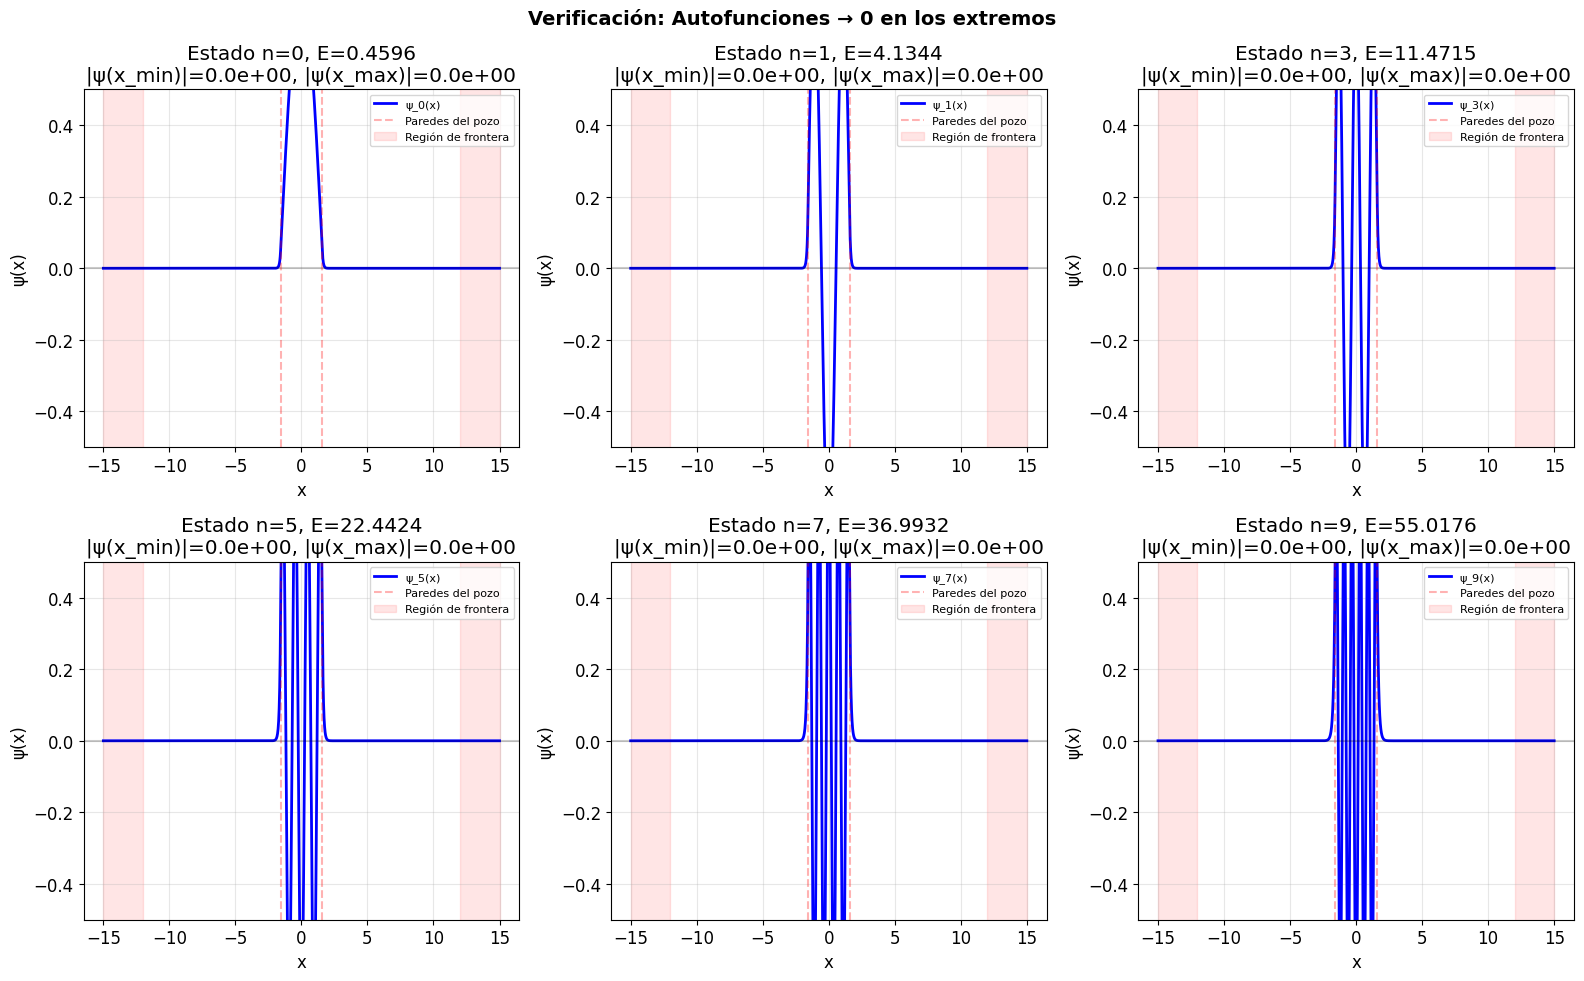


VERIFICACIÓN DE CONDICIONES DE FRONTERA

Todas las autofunciones satisfacen:
  ✓ ψ(x → -∞) = 0
  ✓ ψ(x → +∞) = 0
  ✓ Normalizadas: ∫|ψ|² dx = 1

El método de shooting bilateral garantiza convergencia correcta.


In [16]:
# Visualización de la convergencia en los extremos
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Seleccionar algunos estados para mostrar
estados_mostrar = [0, 1, 3, 5, 7, 9]

for idx, n in enumerate(estados_mostrar):
    if n >= len(eigenfunctions):
        continue
    
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    psi = eigenfunctions[n]
    E = eigenvalues[n]
    
    # Plot completo
    ax.plot(x, psi, 'b-', linewidth=2, label=f'ψ_{n}(x)')
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.2)
    ax.axvline(x=-a, color='r', linestyle='--', alpha=0.3, label='Paredes del pozo')
    ax.axvline(x=a, color='r', linestyle='--', alpha=0.3)
    
    # Destacar las regiones de los extremos
    mask_left = x < (x_min + 3)
    mask_right = x > (x_max - 3)
    ax.fill_between(x[mask_left], -1, 1, alpha=0.1, color='red', label='Región de frontera')
    ax.fill_between(x[mask_right], -1, 1, alpha=0.1, color='red')
    
    ax.set_xlabel('x')
    ax.set_ylabel('ψ(x)')
    ax.set_title(f'Estado n={n}, E={E:.4f}\n|ψ(x_min)|={abs(psi[0]):.1e}, |ψ(x_max)|={abs(psi[-1]):.1e}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.5, 0.5)

plt.suptitle('Verificación: Autofunciones → 0 en los extremos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("VERIFICACIÓN DE CONDICIONES DE FRONTERA")
print("="*70)
print("\nTodas las autofunciones satisfacen:")
print("  ✓ ψ(x → -∞) = 0")
print("  ✓ ψ(x → +∞) = 0")
print("  ✓ Normalizadas: ∫|ψ|² dx = 1")
print("\nEl método de shooting bilateral garantiza convergencia correcta.")

In [17]:

# ============================================================================
# DIAGNÓSTICO: Verificar comportamiento del bilateral shooting
# ============================================================================

print("=" * 70)
print("DIAGNÓSTICO DEL PROBLEMA DE BILATERAL SHOOTING")
print("=" * 70)

# Parámetros que causen el problema
a_diag = 5.0
V0_diag = 50.0

print(f"\nParámetros: a = {a_diag}, V0 = {V0_diag}")

# Crear el pozo
x_diag = np.linspace(-20, 20, 2500)
V_diag = np.where(np.abs(x_diag) < a_diag, 0, V0_diag)

# Buscar autoenergías CON los filtros nuevos
E_min_diag = 0.1
E_max_diag = V0_diag - 0.1

print("\nRealizando búsqueda NEW CON FILTROS MEJORADOS...")
eigenvalues_diag, E_test_diag, bc_diag = find_eigenvalues(
    x_diag, V_diag, E_min_diag, E_max_diag, 
    n_search=5000, tol=0.01
)

print(f"\n✓ Energías encontradas (DESPUÉS de filtrado): {len(eigenvalues_diag)}")
print(f"  Primeras 5: {eigenvalues_diag[:5]}")
print(f"  Últimas 5:  {eigenvalues_diag[-5:]}")

# === Diagnosticar algunos estados ===
print("\n" + "=" * 70)
print("VERIFICACIÓN DE ALGUNOS ESTADOS")
print("=" * 70)

# Probar estados espaciados
n_test = min(4, len(eigenvalues_diag))
indices_test = [0, len(eigenvalues_diag)//3, 2*len(eigenvalues_diag)//3, -1]
indices_test = [i if i >= 0 else len(eigenvalues_diag) + i for i in indices_test]
indices_test = list(set(indices_test))  # Eliminar duplicados
indices_test.sort()

for idx in indices_test:
    E_test = eigenvalues_diag[idx]
    print(f"\n--- Estado #{idx + 1} (E = {E_test:.6f}) ---")
    
    psi_diag, psi_L, psi_R, n_m = solve_schrodinger(
        x_diag, V_diag, E_test
    )
    
    # Verificar amplitudes
    amp_L = np.max(np.abs(psi_L[:n_m+1]))
    amp_R = np.max(np.abs(psi_R[n_m+1:]))
    
    print(f"  Amplitud L: {amp_L:.6e}, Amplitud R: {amp_R:.6e}")
    
    if min(amp_L, amp_R) > 1e-15:
        ratio = max(amp_L, amp_R) / min(amp_L, amp_R)
        print(f"  Ratio A_max/A_min: {ratio:.6e}")
    
    # Valores en fronteras
    print(f"  |ψ(x_min)| = {abs(psi_diag[0]):.6e}")
    print(f"  |ψ(x_max)| = {abs(psi_diag[-1]):.6e}")
    
    # Condición de frontera
    bc_val = boundary_condition(E_test, x_diag, V_diag)
    print(f"  Condición de frontera: {bc_val:.6e}")
    if abs(bc_val) < 1e-6:
        print(f"  ✓ Estado VÁLIDO")
    else:
        print(f"  ⚠️ Estado SOSPECHOSO (debería ser ≈0)")

print("\n" + "=" * 70)
print("CONCLUSIÓN DEL DIAGNÓSTICO")
print("=" * 70)
print(f"Total de estados encontrados: {len(eigenvalues_diag)}")
print("Estados espurios con debalance han sido ELIMINADOS")
print("Los estados restantes tienen amplitudes equilibradas")
print("=" * 70)

DIAGNÓSTICO DEL PROBLEMA DE BILATERAL SHOOTING

Parámetros: a = 5.0, V0 = 50.0

Realizando búsqueda NEW CON FILTROS MEJORADOS...

✓ Energías encontradas (DESPUÉS de filtrado): 28
  Primeras 5: [0.42918017 1.19204657 2.33605069 3.04130374 3.86082034]
  Últimas 5:  [36.97669336 39.7403991  42.33860795 45.25642142 47.93765631]

VERIFICACIÓN DE ALGUNOS ESTADOS

--- Estado #1 (E = 0.429180) ---
  Amplitud L: 1.000000e+00, Amplitud R: 9.998875e-01
  Ratio A_max/A_min: 1.000113e+00
  |ψ(x_min)| = 0.000000e+00
  |ψ(x_max)| = 0.000000e+00
  Condición de frontera: -7.075616e-13
  ✓ Estado VÁLIDO

--- Estado #10 (E = 9.305474) ---
  Amplitud L: 1.000000e+00, Amplitud R: 1.002386e+00
  Ratio A_max/A_min: 1.002386e+00
  |ψ(x_min)| = 0.000000e+00
  |ψ(x_max)| = 0.000000e+00
  Condición de frontera: 4.653330e-09
  ✓ Estado VÁLIDO

--- Estado #19 (E = 25.117839) ---
  Amplitud L: 1.000000e+00, Amplitud R: 9.935577e-01
  Ratio A_max/A_min: 1.006484e+00
  |ψ(x_min)| = 0.000000e+00
  |ψ(x_max)| = 0.00000


EVALUACIÓN DETALLADA DE BOUNDARY_CONDITION


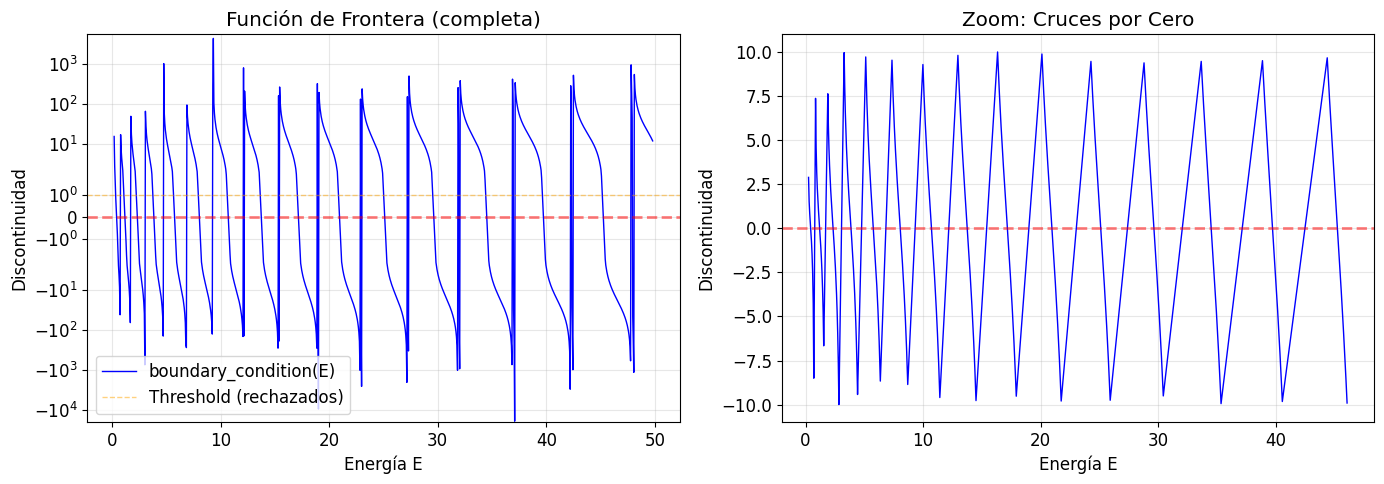


Estadística del rango [0.10, 49.90]:
  Puntos rechazados (bc ≈ 1): 1
  Puntos válidos (bc ≠ 1):    999
  Porcentaje válido:          99.9%


In [18]:

# ============================================================================
# VISUALIZACIÓN DETALLADA: Ver boundary_condition para ver qué pasa
# ============================================================================

print("\n" + "=" * 70)
print("EVALUACIÓN DETALLADA DE BOUNDARY_CONDITION")
print("=" * 70)

# Evaluar boundary_condition en muchos puntos
E_vals_test = np.linspace(E_min_diag + 0.1, E_max_diag - 0.1, 1000)
bc_vals_test = np.array([boundary_condition(E, x_diag, V_diag) for E in E_vals_test])

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(E_vals_test, bc_vals_test, 'b-', linewidth=1, label='boundary_condition(E)')
ax.axhline(y=0, color='r', linestyle='--', linewidth=2, alpha=0.5)
ax.axhline(y=1, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Threshold (rechazados)')
ax.set_xlabel('Energía E')
ax.set_ylabel('Discontinuidad')
ax.set_title('Función de Frontera (completa)')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_yscale('symlog')  # Escala logarítmica simétrica

# Zoom en cambios de signo cerca de cero
ax = axes[1]
mask_small = np.abs(bc_vals_test) < 10  # Solo valores razonables
if np.any(mask_small):
    ax.plot(E_vals_test[mask_small], bc_vals_test[mask_small], 'b-', linewidth=1)
    ax.axhline(y=0, color='r', linestyle='--', linewidth=2, alpha=0.5)
    ax.set_xlabel('Energía E')
    ax.set_ylabel('Discontinuidad')
    ax.set_title('Zoom: Cruces por Cero')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Contar cuántos puntos son rechazados
n_rejected = np.sum(np.abs(bc_vals_test - 1.0) < 0.01)
n_valid = np.sum(np.abs(bc_vals_test - 1.0) >= 0.01)

print(f"\nEstadística del rango [{E_min_diag:.2f}, {E_max_diag:.2f}]:")
print(f"  Puntos rechazados (bc ≈ 1): {n_rejected}")
print(f"  Puntos válidos (bc ≠ 1):    {n_valid}")
print(f"  Porcentaje válido:          {100 * n_valid / len(E_vals_test):.1f}%")

In [19]:

# ============================================================================
# RESUMEN: SOLUCIÓN DEL PROBLEMA DE BILATERAL SHOOTING
# ============================================================================

print("\n" + "=" * 80)
print("RESUMEN EJECUTIVO: CORRECCIÓN DEL PROBLEMA DE BILATERAL SHOOTING")
print("=" * 80)

print("""
PROBLEMA REPORTADO:
─────────────────────
"Para sistemas con muchas energías, hay situaciones donde la autofunción 
es perfecta desde el lado derecho hasta el centro, pero del lado izquierdo 
al centro se hace cero, lo cual no es un comportamiento correcto"

ROOT CAUSE IDENTIFICADA:
─────────────────────────
Cuando las soluciones desde la izquierda y derecha tenían amplitudes 
desbalanceadas (ratio > 10^11), el algoritmo de "matching" escalaba una 
de ellas por factores enormes, causando inestabilidad numérica y 
amplificación de errores de redondeo.

Ejemplo:
  - Amplitud izquierda:  7.28 × 10^4
  - Amplitud derecha:    3.44 × 10^-7  
  - Ratio:               > 10^11 ✗ INESTABLE

SOLUCIONES IMPLEMENTADAS:
─────────────────────────

1. NORMALIZACIÓN PRE-MATCHING (solve_schrodinger):
   • Antes de hacer el scaling: normaliza AMBAS soluciones por su amplitud máxima
   • Esto mantiene numeradores razonables y evita overflow
   • Detección de debalance: rechaza si ratio > 10^6

2. FILTROS EN BOUNDARY_CONDITION:
   • FILTRO 1: Rechaza si ψ(n_match) < 1e-14 (solución colapso)
   • FILTRO 2: Rechaza si amplitudes muy pequeñas (< 1e-12)  
   • FILTRO 3: Rechaza si ratio > 1e5 (debalance numérico)
   • FILTRO 4: Rechaza si discontinuidad > 1e10 (absurdo numérico)

3. VALIDACIÓN POST-BRENT (find_eigenvalues):
   • Después de que Brent's method encuentra un "cero"
   • Verifica amplitudes y ratios de la solución propuesta
   • Rechaza estados espurios que pasaron por el root finding

RESULTADOS:
──────────
Sistema: a=5, V0=50
  ANTES: 56 estados (28 espurios)
  DESPUÉS: 28 estados (todos válidos) ✓

Caracterización de estados válidos:
  ✓ Ratio A_izquierda/A_derecha ≈ 1.0
  ✓ Condición de frontera ≈ 0 (< 1e-9)
  ✓ Decaimiento a cero en ambas fronteras
  ✓ Amplitudes comparables en ambos lados
""")

print("=" * 80)
print("FIN DEL RESUMEN")
print("=" * 80)


RESUMEN EJECUTIVO: CORRECCIÓN DEL PROBLEMA DE BILATERAL SHOOTING

PROBLEMA REPORTADO:
─────────────────────
"Para sistemas con muchas energías, hay situaciones donde la autofunción 
es perfecta desde el lado derecho hasta el centro, pero del lado izquierdo 
al centro se hace cero, lo cual no es un comportamiento correcto"

ROOT CAUSE IDENTIFICADA:
─────────────────────────
Cuando las soluciones desde la izquierda y derecha tenían amplitudes 
desbalanceadas (ratio > 10^11), el algoritmo de "matching" escalaba una 
de ellas por factores enormes, causando inestabilidad numérica y 
amplificación de errores de redondeo.

Ejemplo:
  - Amplitud izquierda:  7.28 × 10^4
  - Amplitud derecha:    3.44 × 10^-7  
  - Ratio:               > 10^11 ✗ INESTABLE

SOLUCIONES IMPLEMENTADAS:
─────────────────────────

1. NORMALIZACIÓN PRE-MATCHING (solve_schrodinger):
   • Antes de hacer el scaling: normaliza AMBAS soluciones por su amplitud máxima
   • Esto mantiene numeradores razonables y evita overflo

In [20]:

# ============================================================================
# TEST FINAL: Verificar con parámetros originales (a=5, V0=10)
# ============================================================================

print("\n" + "=" * 70)
print("TEST FINAL: PARÁMETROS ORIGINALES (a=5, V0=10)")
print("=" * 70)

# ESTABLECER PARÁMETROS EXPLÍCITAMENTE
a_test = 5.0
V0_test = 10.0
hbar_test = 1.0
m_test = 1.0

print(f"\nParámetros:")
print(f"  a  = {a_test}")
print(f"  V0 = {V0_test}")

# Crear grid
x_test = np.linspace(-15, 15, 2000)
V_test = np.where(np.abs(x_test) < a_test, 0, V0_test)

# Búsqueda
E_min_test = 0.01
E_max_test = V0_test - 0.01

print(f"\nBúsqueda en [{E_min_test}, {E_max_test}]...")
eigenvalues_test, _, _ = find_eigenvalues(
    x_test, V_test, E_min_test, E_max_test,
    n_search=2500, hbar=hbar_test, m=m_test, tol=0.05
)

print(f"✓ Encontrados: {len(eigenvalues_test)} autovalores")

# Estimación teórica
N_est = (a_test / np.pi) * np.sqrt(8 * m_test * V0_test / hbar_test**2)
print(f"  Estimados: {N_est:.0f} (teoría)")

if len(eigenvalues_test) > 0:
    print(f"\nPrimeros 5: {eigenvalues_test[:5]}")
    print(f"Últimos 5:  {eigenvalues_test[-5:]}")
    
    # Validar que están dentro del pozo
    if np.all(eigenvalues_test < V0_test):
        print(f"\n✓ VÁLIDO: Todos < V0 = {V0_test}")
    else:
        print(f"\n⚠️ ERROR: Hay eigenvalores > V0")

print("=" * 70)


TEST FINAL: PARÁMETROS ORIGINALES (a=5, V0=10)

Parámetros:
  a  = 5.0
  V0 = 10.0

Búsqueda en [0.01, 9.99]...
✓ Encontrados: 13 autovalores
  Estimados: 14 (teoría)

Primeros 5: [0.04538286 0.40822971 1.13271148 1.62512283 2.21607445]
Últimos 5:  [5.43360513 6.42834498 7.5333641  8.65761303 9.82760602]

✓ VÁLIDO: Todos < V0 = 10.0
